In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import re
import io
from pathlib import Path
from core.normalizer import compute_wallmid3, compute_wallmid2, compute_wallmid1

In [6]:
#SIM DATA PROP 4
log_path=Path("/Users/alexoddsh/prosperity/backend/logs/53bc40ff-8808-4d7d-84b6-53a32cab4d8d_67226.log")
data = json.loads(log_path.read_text())
ai = data["activitiesLog"]
th = data["tradeHistory"]
ied = data["logs"]

prices = pd.read_csv(io.StringIO(ai), sep=";")
trades = pd.DataFrame(th)

prices["day"] = 1
trades["day"] = 1

#TUTORIAL DATA PROP 4
log_path2=Path("/Users/alexoddsh/prosperity/backend/logs/55375961-932b-4308-92cb-7efd894ebbc6.log")
text = log_path2.read_text()
ai2 = text.find("Activities log:\n")
ti2 = text.find("Trade History:\n")

if ai2 == -1 or ti2 == -1:
    raise ValueError("  [ERROR]: Could not find Activities log or Trade History ---")

prices_str = text[ai2 + len("Activities log:\n"):ti2].strip()
prices2 = pd.read_csv(io.StringIO(prices_str), sep=";")

time_to_day = dict(zip(prices2['timestamp'], prices2['day']))
trade_str = text[ti2 + len("Trade History:\n"):].strip()
trade_str = re.sub(r',\s*([}\]])', r'\1', trade_str)
trades2 = pd.DataFrame(json.loads(trade_str))
trades2['day'] = trades2['timestamp'].map(time_to_day)

#OLD DATA PROP 3
old_log_path=Path("/Users/alexoddsh/prosperity/backend/logs/bfd722f3-7c14-4e0f-abc5-b91e80150bd1.log")
text = old_log_path.read_text()
ai3 = text.find("Activities log:\n")
ti3 = text.find("Trade History:\n")

if ai3 == -1 or ti3 == -1:
    raise ValueError("  [ERROR]: Could not find Activities log or Trade History ---")

prices_str = text[ai3 + len("Activities log:\n"):ti3].strip()
prices3 = pd.read_csv(io.StringIO(prices_str), sep=";")

time_to_day = dict(zip(prices3['timestamp'], prices3['day']))
trade_str_1 = text[ti3 + len("Trade History:\n"):].strip()
trade_str_1 = re.sub(r',\s*([}\]])', r'\1', trade_str_1)
trades3 = pd.DataFrame(json.loads(trade_str_1))
trades3['day'] = trades3['timestamp'].map(time_to_day)



FileNotFoundError: [Errno 2] No such file or directory: '/Users/alexoddsh/prosperity/backend/logs/53bc40ff-8808-4d7d-84b6-53a32cab4d8d_67226.log'

count    2000.000000
mean       -0.015669
std         1.686302
min        -2.929688
25%        -1.464844
50%        -0.023438
75%         1.426758
max         2.958984
dtype: float64


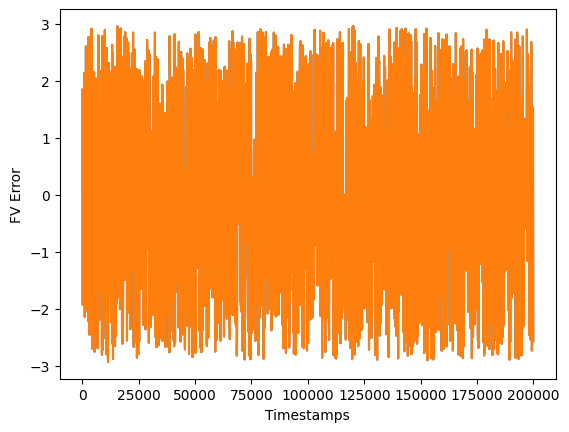

In [37]:
success1 = compute_wallmid3("TOMATOES", prices)
success2 = compute_wallmid2("TOMATOES", prices)
success3 = compute_wallmid1("TOMATOES", prices)

mask = prices["product"] == "TOMATOES"

if success1 and success2 and success3:
    entry_price = trades[trades["symbol"] == "TOMATOES"].iloc[0]["price"]
    trade_qty = trades[trades["symbol"] == "TOMATOES"].iloc[0]["quantity"]
    
    for i in prices[mask].index:
        mid_gap = prices.loc[i, "mid_price"] - entry_price
        wall_gap= prices.loc[i, "wallmid3"] - entry_price
        wall2_gap = prices.loc[i, "wallmid2"] - entry_price
        wall3_gap = prices.loc[i, "wallmid1"] - entry_price

        mid_pnl = mid_gap *trade_qty
        wall_pnl = wall_gap * trade_qty
        wall2_pnl = wall2_gap * trade_qty
        wall3_pnl = wall3_gap * trade_qty

        prices.loc[i, "mid_pnl"] = mid_pnl
        prices.loc[i, "wall_pnl"] = wall_pnl
        prices.loc[i, "wall2_pnl"] = wall2_pnl
        prices.loc[i, "wall3_pnl"] = wall3_pnl


timestamps = prices[prices["product"] == "TOMATOES"]["timestamp"]
pnls = prices[prices["product"] == "TOMATOES"]["profit_and_loss"]

error_mid = pnls - prices[prices["product"] == "TOMATOES"]["mid_pnl"]
error_wall = pnls - prices[prices["product"] == "TOMATOES"]["wall_pnl"]
error_wall2 = pnls - prices[prices["product"] == "TOMATOES"]["wall2_pnl"]
error_wall3 = pnls - prices[prices["product"] == "TOMATOES"]["wall3_pnl"]

error_mid.iloc[0] = 0
error_wall.iloc[0] = 0
error_wall2.iloc[0] = 0
error_wall3.iloc[0] = 0

spread = prices["ask_price_1"] - prices["bid_price_1"]

#print(error_wall.describe())
print(error_wall.describe())

plt.plot(timestamps, error_wall)
plt.plot(timestamps, error_wall2)
plt.ylabel("FV Error")
plt.xlabel("Timestamps")
plt.show()


Above we have "proven" that wallmid 2 is a reliable indicator for FV time T.

In [5]:
mask = prices["product"] == "TOMATOES"
timestamps = prices.loc[mask, "timestamp"]

for i in prices[mask].index:
    prices.loc[i, "ask"] = max(prices.loc[i, "ask_price_2"], prices.loc[i, "ask_price_3"])
    prices.loc[i, "bid"] = min(prices.loc[i, "bid_price_2"], prices.loc[i, "bid_price_3"]) 
    
    if pd.notna(prices.loc[i, "ask_price_3"]):
        prices.loc[i, "ask_vol"] = prices.loc[i, "ask_volume_3"] 
    else:
        prices.loc[i, "ask_vol"] = prices.loc[i, "ask_volume_2"]

    if pd.notna(prices.loc[i, "bid_price_3"]):
        prices.loc[i, "bid_vol"] = prices.loc[i, "bid_volume_3"] 
    else:
        prices.loc[i, "bid_vol"] = prices.loc[i, "bid_volume_2"]

prices = prices.copy()

spread = prices["ask"] - prices["bid"]
volspread = prices["ask_vol"] - prices["bid_vol"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(timestamps, prices.loc[mask, "ask"])
axes[0].plot(timestamps, prices.loc[mask, "bid"])
axes[0].set_xlabel("Price")

axes[1].plot(timestamps, volspread[mask])
axes[1].set_xlabel("Volumes Spread")

plt.tight_layout()
plt.show()

print(spread.mean())

NameError: name 'prices' is not defined

This above is likely the "informed maker" that prev teams talked about, as we can see they quote symmetrically volume wise always and keep a constant spread of 16. Notice how following this makers mid would be exactly the same as our existing wallmid calculation. 

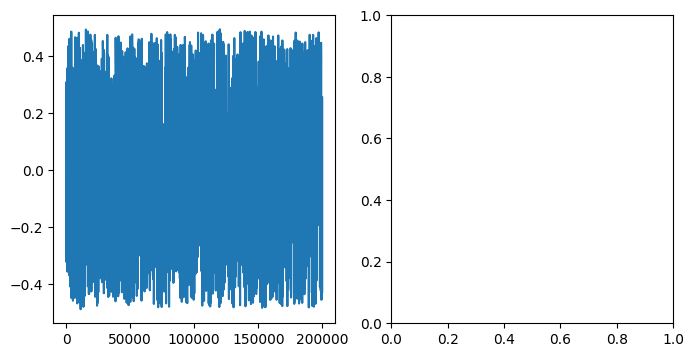

In [40]:
success1 = compute_wallmid3("TOMATOES", prices)
mask = prices["product"] == "TOMATOES"

if success1:
    entry_price = trades[trades["symbol"] == "TOMATOES"].iloc[0]["price"]
    trade_qty = trades[trades["symbol"] == "TOMATOES"].iloc[0]["quantity"]
    
    for i in prices[mask].index:
        wall_gap= prices.loc[i, "wallmid3"] - entry_price
        wall_pnl = wall_gap * trade_qty
        prices.loc[i, "wall_pnl"] = wall_pnl

timestamps = prices[prices["product"] == "TOMATOES"]["timestamp"]
pnls = prices[prices["product"] == "TOMATOES"]["profit_and_loss"]

error_wall = (pnls - prices[prices["product"] == "TOMATOES"]["wall_pnl"]) / trade_qty
error_wall.iloc[0] = 0

for i in error_wall.index:
    if abs(error_wall.loc[i]) > 2.9:
        print(prices.loc[i, "timestamp"])

fig, plots = plt.subplots(1, 2, figsize=(8, 4))

plots[0].plot(timestamps, error_wall)


As we can see the real price error between FV and wallmid3 is drifting between 0.5 and -0.5, my only idea to "close" this gap is to to check for correlation between different OB mechanics and the error to try and see how we can close the gap. 

In [41]:
#dependent
mask = (prices["product"] == "TOMATOES") & (prices["timestamp"] > 0) 

exact_fv = entry_price + (prices.loc[mask,"profit_and_loss"] / trade_qty)
wallmid = prices.loc[mask, "wallmid3"]
residual = exact_fv - wallmid

#independent vars
bid_vol_1 = prices.loc[mask, "bid_volume_1"]
bid_vol_2 = prices.loc[mask, "bid_volume_2"]
bid_vol_3 = prices.loc[mask, "bid_volume_3"]
ask_vol_1 = prices.loc[mask, "ask_volume_1"]
ask_vol_2 = prices.loc[mask, "ask_volume_2"]
ask_vol_3 = prices.loc[mask, "ask_volume_3"]
bid_vol_total = prices.loc[mask, "bid_volume_1"].fillna(0) + prices.loc[mask, "bid_volume_2"].fillna(0) + prices.loc[mask, "bid_volume_3"].fillna(0)
ask_vol_total = prices.loc[mask, "ask_volume_1"].fillna(0) + prices.loc[mask, "ask_volume_2"].fillna(0) + prices.loc[mask, "ask_volume_3"].fillna(0)
vol_imbalance = abs(ask_vol_total-bid_vol_total)

bid_price_1 = prices.loc[mask, "bid_price_1"]
ask_price_1 = prices.loc[mask, "ask_price_1"]
avg_wall_spread = ((wallmid - bid_price_1) + (ask_price_1-wallmid)) / 2
normal_mid = (bid_price_1 + ask_price_1) / 2
mid_offset = normal_mid - wallmid

INDEPENDENTS = {
    "bid_vol_1": bid_vol_1, 
    "bid_vol_2": bid_vol_2, 
    "bid_vol_3": bid_vol_3, 
    "ask_vol_1": ask_vol_1, 
    "ask_vol_2": ask_vol_2, 
    "ask_vol_3": ask_vol_3, 
    "bid_vol_tot": bid_vol_total, 
    "ask_vol_tot": ask_vol_total,
    "vol_imbalance": vol_imbalance, 
    "wall_spread": avg_wall_spread,
    "normal_mid": normal_mid,
    "mid_offset": mid_offset
}

for name, var in INDEPENDENTS.items():
    print(f"{name}: {residual.corr(var)}")

under = 0
mid = 0
over = 0

for i in mid_offset.index:
    if mid_offset[i] == -0.5:
        under += 1
    elif mid_offset[i] == 0.5:
        over += 1
    elif mid_offset[i] == 0.0:
        mid += 1

print(f"{under} -- {mid} -- {over}")

bid_vol_1: -0.03101346541160564
bid_vol_2: 0.005548287081711119
bid_vol_3: -0.1749841818195565
ask_vol_1: -0.024628826614227696
ask_vol_2: 0.00032637082755664895
ask_vol_3: -0.05326549192883741
bid_vol_tot: -0.026964486308339124
ask_vol_tot: -0.02070207395181788
vol_imbalance: -0.027801763896155966
wall_spread: 0.023515719879022692
normal_mid: 0.005098926527126989
mid_offset: 0.3588636060656005
477 -- 931 -- 466


We can see that the offset between the actual mid and wallmid is very evenly distributed 25% 50% 25% around [-0.5, 1, 0,5] why these discrete values? Because wallmid is a float and mid is a float and we always have 2 or 3 levels in discrete hops. But we do not always have the same amount of levels:

symmetric
- A2 = n+2
- A1 = n+1

- B1 = n-1
- B2 = n-2

-> mid = n -> wallmid = n

Here mid and wallmid are always the same. They only differ +/- 0.5 when 

asymmetric
- A3 = n+3
- A2 = n+2
- A1 = n+1

- B1 = n-1
- B2 = n-2

-> mid = n -> wallmid = n+0.5 

And the other way around for wallmid = n-0.5

As such we have 3 discrete groups of offset where the "real time noisy" mid is shifting from wallmid. My idea is that the IRL mid isnt FV ofc but captures the FV "change" more directly/better because it moves directly instead of wallmid where our "informed maker" might move only after the fact that other market participants have changed their view on price.

The idea is to not think of this maker as "informed" in that sense, he is simply a good proxy for FV since his quotes dont
oscillate up and down between t and t+1. Aka his levels only move when price is meaninfully shifting but IS he shifting price or more LIKELY is FV shifting and then he follows? Then this "noisy" trade at t+1 will temporarily tell us a bit more about FV than or not more per say but in which direction wallmid (aka the maker) is "lagging". 

The key here could be to section our 3 discrete groups and say for example: "IF mid offset = 0.5" -> residual between exact_fv and wallmid is in the 0-0.5 group. (remember we have already showed above that the error between wallmid and FV drifts between -0.5 and 0.5). 

That means that currently our best guess for FV in our bot is 0 (the mean of the error aka wallmid). But with the above we could perhaps say:
- mid_offset = -0.5 -> residual is in [-0.5, 0]
- mid_offset = 0.0 -> residual is [0] or also [-0.5, 0.5]??
- mid_offset = 0.5 -> residual is [0, 0.5] 

See the idea? If we could say this then our wallmid guess of FV isnt longer between [-0,5 -> 0.5] error it could be mid of [-0,5, 0] -> -0.25 or [0, 0,5] -> 0.25

In [42]:
under = []
middle = []
over = []

for res, off in zip(residual, mid_offset):
    if off == -0.5:
        under.append(res)
    if off == 0.0:
        middle.append(res)
    if off == 0.5:
        over.append(res)

print(sum(under) / len(under))
print(sum(middle) / len(middle))
print(sum(over) / len(over))

-0.3657673556516359
0.000481812790909418
0.3680522956902744


Solid? we have "confirmed" I think? AND LOOK at that 0.000 mean in group middle. I was correct above I think? If mid is a bit under wallmid then our error between wallmid and the FV is also negative and vice versa, we get:

- Mid > Wallmid -> we are ~0.37 OVER the actual FV
- Mid = Wallmid -> we are at the actual FV
- Mid < Wallmid 


[-0.5, -0,25] [-0.25, 0.25] [0.25, 0.5]

-0.5 ----- 0.0 ------- 0.5
25%        50%.       25%
/////XXXXXXXXXXXXXX/////////

wallmid = 100
FV 100.37

99
100


In [ ]:
from core.classification import compute_classes
success1 = compute_classes("TOMATOES", prices2, trades2)
success2 = compute_classes("TOMATOES", prices, trades)
success3 = compute_classes("KELP", prices3, trades3)

tomato_trades_testday = trades[trades["symbol"] == "TOMATOES"].reset_index(drop=True)
tomato_prices_testday = prices[prices["product"] == "TOMATOES"].reset_index(drop=True)

tomato_trades = trades2[trades2["symbol"] == "TOMATOES"].reset_index(drop=True)
tomato_prices = prices2[prices2["product"] == "TOMATOES"].reset_index(drop=True)

tomato_trades_kelp = trades3[trades3["symbol"] == "KELP"].reset_index(drop=True)
tomato_prices_kelp = prices3[prices3["product"] == "KELP"].reset_index(drop=True)


informed_trades = 0
uninformed_trades = 0
day_2 = tomato_prices[tomato_prices["timestamp"] < 1000000]
day_1 = tomato_prices[tomato_prices["timestamp"] >= 1000000]
day_2_high = day_2["mid_price"].max()
day_1_high = day_1["mid_price"].max()
spread_days = (tomato_prices["ask_price_1"] - tomato_prices["bid_price_1"]).mean()
tolerances = []

if success1:
    for i in tomato_trades.index:
        if tomato_trades.loc[i, "seller_class"] in ["MAKER1"] and tomato_trades.loc[i, "quantity"] > 5:
            if tomato_trades.loc[i, "timestamp"] < 1000000: 
                tolerance = day_2_high - tomato_trades.loc[i, "price"] 
                tolerances.append(float(tolerance))
            if tomato_trades.loc[i, "timestamp"] >= 1000000: 
                tolerance = day_1_high - tomato_trades.loc[i, "price"] 
                tolerances.append(float(tolerance))
            if i + 20 < len(tomato_trades):
                time = tomato_trades.loc[i, "timestamp"]
                fp = tomato_prices[tomato_prices["timestamp"] == time+1000*100]["mid_price"].item()
                informed_trades +=1
                tomato_trades.loc[i, "seller_fp_informed"] = fp - tomato_trades.loc[i, "price"]
        
        if tomato_trades.loc[i, "seller_class"] in ["MAKER1"] and tomato_trades.loc[i, "quantity"] <= 5:
            if i + 20 < len(tomato_trades):
                time = tomato_trades.loc[i, "timestamp"]
                if time < 900000:
                    fp = tomato_prices[tomato_prices["timestamp"] == time+1000*100]["mid_price"].item()
                    uninformed_trades +=1
                    tomato_trades.loc[i, "seller_fp"] = fp - tomato_trades.loc[i, "price"]

informed_trades_testday = 0
uninformed_trades_testday = 0
day_0_high = tomato_prices_testday["mid_price"].max() 
spread_testday = (tomato_prices_testday["ask_price_1"] - tomato_prices_testday["bid_price_1"]).mean()
tolerances_testday = []

if success2:
    for i in tomato_trades_testday.index:
        if tomato_trades_testday.loc[i, "seller_class"] in ["MAKER1"] and tomato_trades_testday.loc[i, "quantity"] > 5:
            tolerance = day_0_high - tomato_trades_testday.loc[i, "price"] 
            tolerances_testday.append(float(tolerance))
            if i + 20 < len(tomato_trades_testday):
                time = tomato_trades_testday.loc[i, "timestamp"]
                fp = tomato_prices_testday[tomato_prices_testday["timestamp"] == time+1000*100]["mid_price"].item()
                informed_trades_testday +=1
                tomato_trades_testday.loc[i, "seller_fp_informed"] = fp - tomato_trades_testday.loc[i, "price"]

        if tomato_trades_testday.loc[i, "seller_class"] in ["MAKER1"] and tomato_trades_testday.loc[i, "quantity"] <= 5:
            if i + 20 < len(tomato_trades_testday):
                time = tomato_trades_testday.loc[i, "timestamp"]
                if time < 100000:
                    fp = tomato_prices_testday[tomato_prices_testday["timestamp"] == time+1000*100]["mid_price"].item()
                    uninformed_trades_testday +=1
                    tomato_trades_testday.loc[i, "seller_fp"] = fp - tomato_trades_testday.loc[i, "price"]

kelp_spread = (prices3["ask_price_1"] - prices3["bid_price_1"]).mean()

print("TUTORIAL DAY STATS")
print(f"Avg Maker1 Informed Seller FP across days: {tomato_trades["seller_fp_informed"].mean()}")
print(f"Avg Uninformed Seller FP across days: {round(tomato_trades["seller_fp"].mean(), 3)}")
print(f"No. of informed Trades: {informed_trades}")
print(f"No. of uninformed Trades: {uninformed_trades}")
print(f"Avg. Spread: {round(spread_days, 3)}")
print(f"Tolerances against day high in informed trades {[tolerances[0], tolerances[1]]} Avg: {sum(tolerances) / len(tolerances)}")
print(f"Tolerance/Spread Ratio: {round((sum(tolerances) / len(tolerances)) / spread_days, 3)}")

print("")
print("PROSPERITY SIM STATS")
print(f"Avg Maker1 Informed Seller FP across days: {tomato_trades_testday["seller_fp_informed"].mean()}")
print(f"Avg Uninformed Seller FP across days: {tomato_trades_testday["seller_fp"].mean()}")
print(f"No. of informed Trades: {informed_trades_testday}")
print(f"No. of uninformed Trades: {uninformed_trades_testday}")
print(f"Avg. Spread: {round(spread_testday, 3)}")
print(f"Tolerances against day high in informed trade {tolerances_testday[0]}")
print(f"Tolerance/Spread Ratio: {round(tolerances_testday[0] / spread_testday, 3)}")

TUTORIAL DAY STATS
Avg Maker1 Informed Seller FP across days: -16.25
Avg Uninformed Seller FP across days: -5.879
No. of informed Trades: 2
No. of uninformed Trades: 169
Avg. Spread: 13.02
Tolerances against day high in informed trades [5.0, 20.0] Avg: 12.5
Tolerance/Spread Ratio: 0.96

PROSPERITY SIM STATS
Avg Maker1 Informed Seller FP across days: -28.0
Avg Uninformed Seller FP across days: -5.25
No. of informed Trades: 1
No. of uninformed Trades: 18
Avg. Spread: 13.056
Tolerances against day high in informed trade -4.0
Tolerance/Spread Ratio: -0.306

KELP ROUND 1 STATS
Avg Taker1 Informed Seller FP across days: 
Avg Uninformed Seller FP across days: 
No. of informed Trades: 
No. of uninformed Trades: 
Avg. Spread: 
Tolerances against day high in informed trade 
Tolerance/Spread Ratio: 


The hypothesis is based on an informed bot hypothesis. I think this is similar to behaviour in Prosperity 3. Here are my fors and againsts:

FORS:
1. Exactly one trade per day (and in prosperity sim) at qty = 6. This would be somewhat consistent with the idea of fingerprinting traders based on quantity from Squid Ink in prosperity 3.
2. Trades occur near the day high. To be clear the pattern in prosperity 3 in for both Squid Ink and Kelp isn't that Olivia is perfectly at the day high. There is a tolerance of roughly +-2 avg for the concept to work. The tolerance For our data is near 0 in the sim and day -2 but a larger on day -1. However, if we scale this tolerance on day -2 by the average spread of tomatoes vs the average spread of Kelp/Squid Ink we can see validate day -1.
3. As we see above, there is a clear pattern that the potentially informed seller is selling at very good times to sell, even if not strictly "optimal". However since our informed seller is likely otherwise a normal market maker it makes more sense that they wouldnt be able to time their trade perfectly as Olivia does because there simply does not exist enough liquidity at good levels in tomatoes. There is question on how to best "represent" this above is just one way but also visual inspection will confirm the pattern. To be clear it is the combination of very good selling times and the fact that the maker actively moves their ask across the mid one tick before to get the fill.
4. Overall this is also very much in line with prosperity being consistent with their patterns in round 1 and very consistent with the idea of round 1 prosperity 3 with KELP = TOMATOES and SQUID INK = PROD3 where both products have the informed pattern but where the market dynamics of KELP + TOMATOES arent optimal to actually use the information on, instead the information is optimal in the OTHER product. 

AGAINST:
1. The "pattern" with a maker moving their bid or ask across the spread isnt worth trying to "quantify" because in fact it exists everywhere in the data and might not strentghening the pattern at all. Might just be coincidence/general dynamics. 
2. Altough we can make the argument that the larger spread of tomatoes justifies the larger tolerance it still seems a bit unconsistent. Going on the hypothesis that IMC would likely use a very CLEAR pattern for this the tolerance here seems a bit to large in absolute terms. AKA the timing of the trade day -1 isnt clean enough. HOWEVER a very important factor to mention is that to evaluate the "day highs" and "lows" in a fair way between Squid Ink/KELP and Tomatoes we must look at what price does the informed seller execute at. In Squid Ink and Kelp the informed seller is a taker, their best execution is at the highest bid_price_1 during the day. For our informed maker seller that is essentially crossing the spread at t at t+1, their best execution is roughly at the mid price at t. 
3. The above combined with the fact that we dont even have 3 days makes this literally unprovable for now but 100% something to test. 

